# Conference visual bundle — fixed-precision Round 14

This notebook rebuilds the project-owned diagrams and plots used for the
FastML conference material, plus the per-class ROC overlays kept as backup
figures. It is deliberately a **historical, pre-target-enforcement view**.

The scope boundary is concrete:

- included: the fixed-precision Round-14 `r14` ROC arrays and EBOPs table,
  the stored N=8 synthesis reports, and the architecture TikZ source;
- excluded: `ebops-n8-20260910/`, `ebops-n8-costfirst-20260910/`,
  `ebops-n8-long-20260911/`, `ebops-n8-ablation-20260912/`, and every
  checkpoint produced by an enforced EBOPs target;
- no training or synthesis runs here: every number is recomputed from a
  stored `.npz`, JSON, or raw synthesis report.

The notebook writes a fresh bundle under `BNHGQ2_OUT_ROOT` (or the path in
`BNJETTAG_CONFERENCE_OUT`) and never overwrites the frozen conference files.
Each plot is saved as PNG and PDF; the architecture remains TikZ + SVG.

## Visual inventory

| visual | status in this notebook | source of record |
| --- | --- | --- |
| BNJetTag architecture | rendered from project TikZ when `tectonic` is available; otherwise the verified SVG is bundled with its TikZ source | `docs/figures/bnjettag-architecture.tex` |
| AUC vs constituent count | regenerated | 60 Round-14 ROC `.npz` arrays |
| AUC vs EBOPs | regenerated | the same ROC arrays + `ebops_r14.json` |
| per-class ROC overlays, N=8/16/32/64 | regenerated | the same ROC arrays, seed 1 |
| LUT attribution | regenerated | raw HLS instance report + Vivado utilization report |
| BitNet explainer | copied and credited, not redrawn | Wang et al., arXiv:2310.11453, Fig. 2 |
| CMS trigger flow | copied and credited, not redrawn | M. Pierini conference figure |

The last two are externally sourced context figures. Calling a file copy a
generated result would erase that distinction, so the manifest records them
as `reference-only` assets.

## 1 — setup, output directory, and the era firewall

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import csv, hashlib, importlib, json, os, re, shutil, subprocess, sys, tempfile

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, SVG, display
from sklearn.metrics import roc_auc_score, roc_curve

def find_research_root():
    candidates = []
    if os.environ.get("BNJETTAG_REPO"):
        candidates.append(Path(os.environ["BNJETTAG_REPO"]))
    if os.environ.get("PYTHONPATH"):
        for raw in os.environ["PYTHONPATH"].split(os.pathsep):
            p = Path(raw).expanduser()
            if p.name == "hgq2" and len(p.parents) >= 3:
                candidates.append(p.parents[2])
    here = Path.cwd().resolve()
    for base in (here, *here.parents):
        candidates.extend((base, base / "research"))
    seen = set()
    for candidate in candidates:
        try:
            candidate = candidate.expanduser().resolve()
        except OSError:
            continue
        if candidate in seen:
            continue
        seen.add(candidate)
        if ((candidate / "RESEARCH.md").is_file() and
                (candidate / "bnjettag/roc-results/r14").is_dir()):
            return candidate
    raise FileNotFoundError(
        "Cannot find the research tree. Run ./setup.sh or set BNJETTAG_REPO. "
        "The cluster notebook pod normally syncs code only, so run this figure "
        "bundle locally unless the Round-14 result stores are also mounted."
    )

ROOT = find_research_root()
BN = ROOT / "bnjettag"
ROC_ROOT = BN / "roc-results" / "r14"
RESULT_ROOT = BN / "results" / "r14"
default_output = Path(os.environ.get("BNHGQ2_OUT_ROOT", Path.cwd() / "outputs"))
OUT = Path(os.environ.get("BNJETTAG_CONFERENCE_OUT", default_output)) / "conference-pre-ebops"
OUT.mkdir(parents=True, exist_ok=True)

# Era firewall: later target-enforcement stores are never candidates for a load.
FORBIDDEN = (
    "ebops-n8-20260910", "ebops-n8-costfirst-20260910",
    "ebops-n8-long-20260911", "ebops-n8-ablation-20260912",
    "r15-gamma",
)

def source_path(path):
    path = Path(path).resolve()
    text = str(path)
    assert not any(token in text for token in FORBIDDEN), f"post-cutoff source rejected: {path}"
    assert path.is_file(), f"missing source: {path}"
    return path

def relative(path):
    path = Path(path).resolve()
    try:
        return str(path.relative_to(ROOT))
    except ValueError:
        return str(path)

def bundle_relative(path):
    return str(Path(path).resolve().relative_to(OUT.resolve()))

COLORS = {"FP32": "#E78AC3", "W8A8": "#D55E00", "W1A8": "#009E73",
          "W1A6": "#E69F00", "W1A4": "#CC79A7"}
ARMS = ["FP32", "W8A8", "W1A8", "W1A6", "W1A4"]
N_SWEEP = [8, 16, 32, 64]
CLASSES = ["g", "q", "W", "Z", "t"]
N_EVAL = 260_000
ASSETS = []

def save_figure(fig, stem, sources, caption):
    paths = []
    for ext in ("png", "pdf"):
        path = OUT / f"{stem}.{ext}"
        fig.savefig(path, dpi=220 if ext == "png" else None, bbox_inches="tight")
        paths.append(path)
    ASSETS.append({
        "name": stem, "kind": "generated-plot",
        "outputs": [bundle_relative(p) for p in paths],
        "sources": [relative(source_path(p)) for p in sources],
        "caption": caption,
    })
    display(fig)
    plt.close(fig)
    return paths

print("research root :", ROOT)
print("output bundle :", OUT)
print("scope         : fixed-precision Round 14 only; enforced-EBOPs-target runs excluded")

research root : /Users/kaiyamaguchi/Downloads/bnjettag-training-results
output bundle : /Users/kaiyamaguchi/Desktop/bnjettag-lab/local/outputs/conference-pre-ebops
scope         : fixed-precision Round 14 only; enforced-EBOPs-target runs excluded


## 2 — recompute the Round-14 AUC table

All 60 source arrays are checked before plotting: expected input set, era,
metric, five-class shapes, three seeds per arm, and exact agreement between
the recomputed macro one-vs-rest AUC and the value stored in each array's
metadata. The plots below use the recomputation, never the stored summary.

In [2]:
aucs = {}
roc_files = []
rows = []
for n in N_SWEEP:
    for arm in ARMS:
        for seed in (1, 2, 3):
            path = source_path(ROC_ROOT / f"n{n}" / f"{arm}-s{seed}.npz")
            with np.load(path, allow_pickle=True) as data:
                y = data["y"]
                score = data["score"]
                meta = json.loads(str(data["meta"]))
                assert y.shape == score.shape == (N_EVAL, 5), path
                assert meta["era"] == 2 and meta["campaign"] == "final", path
                assert meta["metric"] == "roc_test_auc_macro_ovr", path
                assert meta["key"] == arm and int(meta["seed"]) == seed, path
                per_class = [roc_auc_score(y[:, k], score[:, k]) for k in range(5)]
            macro = float(np.mean(per_class))
            assert abs(macro - float(meta["auc"])) < 1e-12, path
            aucs.setdefault((n, arm), []).append(macro)
            roc_files.append(path)
            rows.append([n, arm, seed, macro, *per_class, relative(path)])

assert len(roc_files) == 60
summary_csv = OUT / "round14_auc_recomputed.csv"
with summary_csv.open("w", newline="") as handle:
    writer = csv.writer(handle)
    writer.writerow(["N", "arm", "seed", "macro_ovr_auc", *[f"auc_{c}" for c in CLASSES], "source"])
    writer.writerows(rows)

print("AUC gate passed: 60/60 arrays; wrote", summary_csv)
print("\nseed mean +/- sample s.d.")
for n in N_SWEEP:
    print(f"N={n:2d}", "  ".join(
        f"{arm}={np.mean(aucs[(n, arm)]):.4f}+/-{np.std(aucs[(n, arm)], ddof=1):.4f}"
        for arm in ARMS))

AUC gate passed: 60/60 arrays; wrote /Users/kaiyamaguchi/Desktop/bnjettag-lab/local/outputs/conference-pre-ebops/round14_auc_recomputed.csv

seed mean +/- sample s.d.
N= 8 FP32=0.8864+/-0.0005  W8A8=0.8862+/-0.0009  W1A8=0.8712+/-0.0016  W1A6=0.8689+/-0.0020  W1A4=0.8534+/-0.0012
N=16 FP32=0.9128+/-0.0013  W8A8=0.9124+/-0.0014  W1A8=0.8956+/-0.0002  W1A6=0.8910+/-0.0009  W1A4=0.8693+/-0.0021
N=32 FP32=0.9374+/-0.0017  W8A8=0.9358+/-0.0011  W1A8=0.9052+/-0.0079  W1A6=0.9022+/-0.0009  W1A4=0.8833+/-0.0013
N=64 FP32=0.9486+/-0.0012  W8A8=0.9448+/-0.0011  W1A8=0.9121+/-0.0116  W1A6=0.9136+/-0.0061  W1A4=0.9073+/-0.0009


## 3 — conference plot: held-out AUC vs constituent count

In [3]:
fig, ax = plt.subplots(figsize=(9.4, 6.3))
for arm in ARMS:
    mu = [np.mean(aucs[(n, arm)]) for n in N_SWEEP]
    sd = [np.std(aucs[(n, arm)], ddof=1) for n in N_SWEEP]
    ax.errorbar(N_SWEEP, mu, yerr=sd, color=COLORS[arm], marker="o",
                markersize=7, linewidth=2.2, capsize=4)
    ax.annotate(arm, (N_SWEEP[-1] * 1.04, mu[-1]), color=COLORS[arm],
                fontsize=14, fontweight="bold", va="center")
ax.set_xscale("log", base=2)
ax.set_xticks(N_SWEEP, [str(n) for n in N_SWEEP])
ax.set_xlim(7, 92)
ax.set_xlabel(r"Constituents per jet, $N$ (top-$N$ by $p_T$)", fontsize=15)
ax.set_ylabel("Held-out macro one-vs-rest AUC", fontsize=15)
ax.set_title("Tagging accuracy vs constituent count, by precision", fontsize=17)
ax.tick_params(labelsize=13)
ax.grid(alpha=0.28)
fig.text(0.5, 0.01,
         "HLS4ML LHC Jet, 5 classes | inputs: pT, eta_rel, phi_rel | "
         "ROC-test n=260,000 | mean +/- sample s.d., 3 seeds | fixed-precision R14",
         ha="center", fontsize=8.5, color="0.35")
fig.tight_layout(rect=[0, 0.035, 1, 1])
save_figure(
    fig, "fig_auc_vs_n_conference_pre_ebops", roc_files,
    "Held-out macro one-vs-rest AUC versus constituent count for the five fixed-precision "
    "Round-14 arms; points show the three-seed mean and bars the sample standard deviation."
)

<Figure size 940x630 with 1 Axes>

[PosixPath('/Users/kaiyamaguchi/Desktop/bnjettag-lab/local/outputs/conference-pre-ebops/fig_auc_vs_n_conference_pre_ebops.png'),
 PosixPath('/Users/kaiyamaguchi/Desktop/bnjettag-lab/local/outputs/conference-pre-ebops/fig_auc_vs_n_conference_pre_ebops.pdf')]

## 4 — conference plot: held-out AUC vs checkpoint EBOPs

In [4]:
ebops_path = source_path(RESULT_ROOT / "ebops_r14.json")
ebops_raw = json.loads(ebops_path.read_text())
assert ebops_raw["convention"].startswith("hgq2_trace_minmax")
ebops = {}
for row in ebops_raw["models"].values():
    key = (int(row["n_part"]), str(row["variant"]).upper())
    ebops.setdefault(key, []).append(float(row["ebops"]))

fig, ax = plt.subplots(figsize=(9.4, 6.3))
for arm in ["W8A8", "W1A8", "W1A6", "W1A4"]:
    x = [np.mean(ebops[(n, arm)]) for n in N_SWEEP]
    y = [np.mean(aucs[(n, arm)]) for n in N_SWEEP]
    yerr = [np.std(aucs[(n, arm)], ddof=1) for n in N_SWEEP]
    ax.errorbar(x, y, yerr=yerr, color=COLORS[arm], marker="o",
                markersize=7, linewidth=2.2, capsize=4)
    ax.annotate(arm, (x[-1] * 1.08, y[-1]), color=COLORS[arm],
                fontsize=14, fontweight="bold", va="center")
    if arm == "W1A8":
        for n, xx, yy in zip(N_SWEEP, x, y):
            ax.annotate(f"N={n}", (xx, yy), xytext=(-8, 9),
                        textcoords="offset points", fontsize=10, color="0.3")
ax.set_xscale("log")
ax.set_xlabel("Estimated bit-operations per jet (EBOPs), three-seed mean", fontsize=15)
ax.set_ylabel("Held-out macro one-vs-rest AUC", fontsize=15)
ax.set_title("Tagging accuracy vs estimated arithmetic cost", fontsize=17)
ax.tick_params(labelsize=13)
ax.grid(alpha=0.28, which="both")
fig.text(0.5, 0.01,
         "HGQ2 trace_minmax checkpoint EBOPs | same R14 ROC-test arrays as AUC-vs-N | "
         "FP32 omitted: it has no quantizers and therefore no checkpoint EBOP count",
         ha="center", fontsize=8.2, color="0.35")
fig.tight_layout(rect=[0, 0.035, 1, 1])
save_figure(
    fig, "fig_auc_vs_ebops_conference_pre_target", [*roc_files, ebops_path],
    "Held-out macro one-vs-rest AUC versus HGQ2 trace_minmax checkpoint EBOPs for the "
    "four quantized fixed-precision Round-14 arms; FP32 is omitted because the metric "
    "is defined from quantizers."
)

<Figure size 940x630 with 1 Axes>

[PosixPath('/Users/kaiyamaguchi/Desktop/bnjettag-lab/local/outputs/conference-pre-ebops/fig_auc_vs_ebops_conference_pre_target.png'),
 PosixPath('/Users/kaiyamaguchi/Desktop/bnjettag-lab/local/outputs/conference-pre-ebops/fig_auc_vs_ebops_conference_pre_target.pdf')]

## 5 — conference backup plots: per-class ROC overlays

HEP convention is enforced here: tagging efficiency (TPR) is the linear x
axis and mistag rate (FPR) is the logarithmic y axis. These overlays use seed
1, matching the existing conference backup figures; AUC-vs-N above carries
the three-seed uncertainty summary.

In [5]:
for n in N_SWEEP:
    selected = [source_path(ROC_ROOT / f"n{n}" / f"{arm}-s1.npz") for arm in ARMS]
    curves = {}
    for arm, path in zip(ARMS, selected):
        with np.load(path, allow_pickle=True) as data:
            y, score = data["y"], data["score"]
            curves[arm] = []
            for k in range(5):
                fpr, tpr, _ = roc_curve(y[:, k], score[:, k])
                curves[arm].append((fpr, tpr, roc_auc_score(y[:, k], score[:, k])))

    fig, axes = plt.subplots(2, 3, figsize=(16.5, 9.6))
    axes = axes.ravel()
    for k, cls in enumerate(CLASSES):
        ax = axes[k]
        for arm in ARMS:
            fpr, tpr, auc = curves[arm][k]
            positive = fpr > 0
            ax.plot(tpr[positive], fpr[positive], color=COLORS[arm], linewidth=1.8,
                    label=f"{arm} (AUC={auc:.4f})")
        ax.set_yscale("log")
        ax.set_xlim(0, 1)
        ax.set_xlabel(f"{cls} tagging efficiency (TPR)", fontsize=11)
        ax.set_ylabel("Mistag rate (FPR, one-vs-rest)", fontsize=11)
        ax.set_title(f"{cls} vs rest", fontsize=13)
        ax.legend(loc="upper left", fontsize=8)
        ax.grid(alpha=0.28, which="both")
    axes[-1].axis("off")
    axes[-1].text(
        0.03, 0.95,
        "Round 14, seed 1\n" + "\n".join(
            f"{arm:5s} macro AUC = {aucs[(n, arm)][0]:.4f}" for arm in ARMS),
        family="monospace", fontsize=12, va="top")
    fig.suptitle(
        f"Per-class ROC — N={n}, pT/eta_rel/phi_rel inputs, fixed-precision Round 14",
        fontsize=16)
    fig.text(0.5, 0.012,
             "HLS4ML LHC Jet, ROC-test n=260,000 | one-vs-rest | seed 1 | "
             "linear tagging-efficiency axis, logarithmic mistag-rate axis",
             ha="center", fontsize=9, color="0.35")
    fig.tight_layout(rect=[0, 0.035, 1, 0.96])
    save_figure(
        fig, f"roc_overlay_n{n}_conference_pre_ebops", selected,
        f"Seed-1 per-class one-vs-rest ROC overlay at N={n}; tagging efficiency is "
        "linear and mistag rate is logarithmic."
    )

<Figure size 1650x960 with 6 Axes>

<Figure size 1650x960 with 6 Axes>

<Figure size 1650x960 with 6 Axes>

<Figure size 1650x960 with 6 Axes>

## 6 — conference plot: where the LUTs go

The bars come from the per-instance table of the raw Vitis HLS report. The
HLS total is read from `csynth_report.json`; the post-Vivado number in the
footer is parsed from `post_opt_util.rpt`. No utilization number is typed
into the plotting cell.

In [6]:
hls_dir = BN / "results/synthesis/runs/38a20c62/w1a8-s3-r14n8-beta1sm4i0/csynth_beta1sm4i0"
rpt_path = source_path(hls_dir / "myproject_csynth.rpt")
csynth_json = source_path(hls_dir / "csynth_report.json")
vivado_util = source_path(hls_dir.parent / "postsyn_xczu7ev/post_opt_util.rpt")

parser_dir = BN / "code/hgq2"
if str(parser_dir) not in sys.path:
    sys.path.insert(0, str(parser_dir))
parse_families = importlib.import_module("parse_families")
families, _instance_rows, trusted = parse_families.load(str(rpt_path))
assert trusted, "the trusted per-instance HLS table is required"

hls_total = int(json.loads(csynth_json.read_text())["LUT"])
match = re.search(r"^\| CLB LUTs\*?\s*\|\s*([0-9,]+)\s*\|", vivado_util.read_text(), re.M)
assert match, "could not parse post-opt CLB LUT total"
vivado_total = int(match.group(1).replace(",", ""))

buckets = [
    ("Binary linear layers (+/-1 weights)", ["einsum_dense", "dense_latency"]),
    ("beta rescaling in LUT logic", ["normalize"]),
    ("Attention activation x activation", ["einsum(actxact)"]),
    ("Activation requantization", ["thresholded_relu"]),
    ("Softmax", ["softmax", "Loop_VITIS_LOOP_408_1_proc", "Loop_VITIS_LOOP_408_1_proc111"]),
    ("Residual adds and pooling", ["add", "global_pooling1d_cl"]),
]
lut_by_family = {key: value["LUT"] for key, value in families.items() if key != "(top-level)"}
used = set()
values = []
for label, keys in buckets:
    count = sum(lut_by_family.get(key, 0) for key in keys)
    used.update(keys)
    values.append((label, count))
ungrouped_modules = sum(value for key, value in lut_by_family.items() if key not in used)
grouped = sum(value for _, value in values)
values.append(("Inter-layer buffers and control", hls_total - grouped))
assert sum(value for _, value in values) == hls_total
values.sort(key=lambda item: item[1], reverse=True)

labels = [label for label, _ in values]
counts = [value for _, value in values]
shares = [100 * value / hls_total for value in counts]
fig, ax = plt.subplots(figsize=(12.5, 6.4))
y_pos = list(range(len(values)))[::-1]
ax.barh(y_pos, shares, color="#0B5394", height=0.62)
for y, share, count in zip(y_pos, shares, counts):
    ax.text(share + 0.6, y, f"{share:.0f}%  ({count/1e3:,.0f}k)",
            va="center", fontsize=14, color="#1A1A1A")
ax.set_yticks(y_pos, labels, fontsize=14)
ax.set_xlabel("Share of HLS-estimated design LUTs (%) — N=8, W1A8", fontsize=14)
ax.set_xlim(0, max(shares) * 1.34)
ax.tick_params(axis="x", labelsize=12, colors="#555F66")
ax.xaxis.grid(True, color="#DDDDDD", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.5, 0.012,
         f"Vitis HLS per-instance attribution: {hls_total:,} LUT total | "
         f"same build after Vivado post-opt: {vivado_total:,} CLB LUT | "
         "shares describe the HLS estimate, not the post-opt netlist",
         ha="center", fontsize=9, color="#555F66")
fig.tight_layout(rect=[0, 0.045, 1, 1])
save_figure(
    fig, "fig_lut_attribution_n8_conference_pre_ebops",
    [rpt_path, csynth_json, vivado_util],
    "Vitis HLS LUT attribution by module family for the N=8 W1A8 fitting "
    "characterization build; percentages use the HLS total, while the parsed "
    "Vivado post-opt total is provided only as implementation context."
)
print("ungrouped module LUTs included in buffers/control:", ungrouped_modules)

<Figure size 1250x640 with 1 Axes>

ungrouped module LUTs included in buffers/control: 210409


## 7 — project diagram: BNJetTag architecture

TikZ remains the source of record. If a local `tectonic` executable is
available, this cell renders that source to PDF, SVG, and PNG. If it is not,
the cell bundles the committed SVG with the exact TikZ source and records the
fallback in the manifest. The fallback is explicit because a copied render is
not a fresh render.

architecture mode: fresh local TikZ render


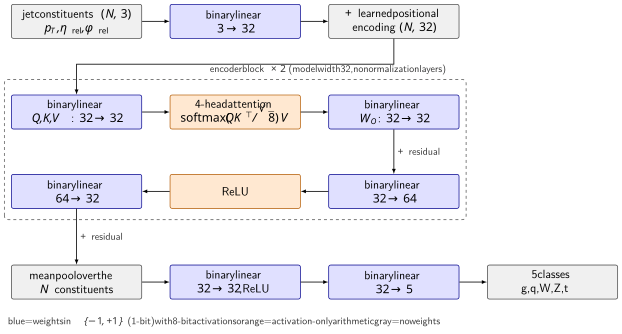

In [7]:
tex_source = source_path(ROOT / "docs/figures/bnjettag-architecture.tex")
svg_source = source_path(ROOT / "docs/figures/bnjettag-architecture.svg")
tex_out = OUT / "bnjettag-architecture.tex"
shutil.copy2(tex_source, tex_out)

tectonic = shutil.which("tectonic")
if tectonic is None and Path("/opt/homebrew/bin/tectonic").is_file():
    tectonic = "/opt/homebrew/bin/tectonic"

render_mode = "fresh local TikZ render"
svg_out = OUT / "bnjettag-architecture.svg"
png_out = OUT / "bnjettag-architecture.png"
pdf_out = OUT / "bnjettag-architecture.pdf"
try:
    if tectonic is None:
        raise FileNotFoundError("tectonic executable is unavailable")
    wrapper = (
        "\\documentclass[tikz,border=4pt]{standalone}\n"
        "\\usepackage{tikz}\n"
        "\\begin{document}\n" + tex_source.read_text() +
        "\n\\end{document}\n"
    )
    with tempfile.TemporaryDirectory(prefix="bnjettag-tikz-", dir=OUT) as tmp:
        tmp = Path(tmp)
        wrapper_path = tmp / "architecture-wrapper.tex"
        wrapper_path.write_text(wrapper)
        completed = subprocess.run(
            [tectonic, "--outdir", str(tmp), str(wrapper_path)],
            cwd=tmp, capture_output=True, text=True, timeout=180)
        if completed.returncode:
            raise RuntimeError(completed.stderr[-2000:])
        shutil.copy2(tmp / "architecture-wrapper.pdf", pdf_out)
    import pymupdf
    document = pymupdf.open(pdf_out)
    page = document[0]
    svg_out.write_text(page.get_svg_image(text_as_path=False))
    page.get_pixmap(matrix=pymupdf.Matrix(3, 3), alpha=False).save(png_out)
    document.close()
    outputs = [tex_out, svg_out, png_out, pdf_out]
except Exception as exc:
    render_mode = f"verified committed SVG fallback ({type(exc).__name__}: {exc})"
    shutil.copy2(svg_source, svg_out)
    try:
        import pymupdf
        document = pymupdf.open(svg_out)
        page = document[0]
        page.get_pixmap(matrix=pymupdf.Matrix(3, 3), alpha=False).save(png_out)
        document.close()
        outputs = [tex_out, svg_out, png_out]
    except Exception:
        outputs = [tex_out, svg_out]

ASSETS.append({
    "name": "bnjettag-architecture", "kind": "generated-diagram",
    "outputs": [bundle_relative(path) for path in outputs],
    "sources": [relative(tex_source), relative(svg_source)],
    "method": render_mode,
    "caption": "BNJetTag fixed-precision Round-14 architecture: L1-realistic (N,3) inputs, "
               "two encoder blocks, binary linear layers, mean pooling, and five-class output."
})
print("architecture mode:", render_mode)
display(SVG(filename=str(svg_out)))

## 8 — externally sourced context diagrams

These are part of the conference visual bundle but are not project-generated
evidence. The notebook preserves the files byte-for-byte, prints their hashes,
displays their credits, and marks them `reference-only` in the manifest.

bitnet-explainer-wang-fig2: b4c037c25c30d7f39dded88c12204e5b50e818a2ee5a15a4263d3c702b90825e | Wang et al., BitNet, arXiv:2310.11453, Fig. 2.


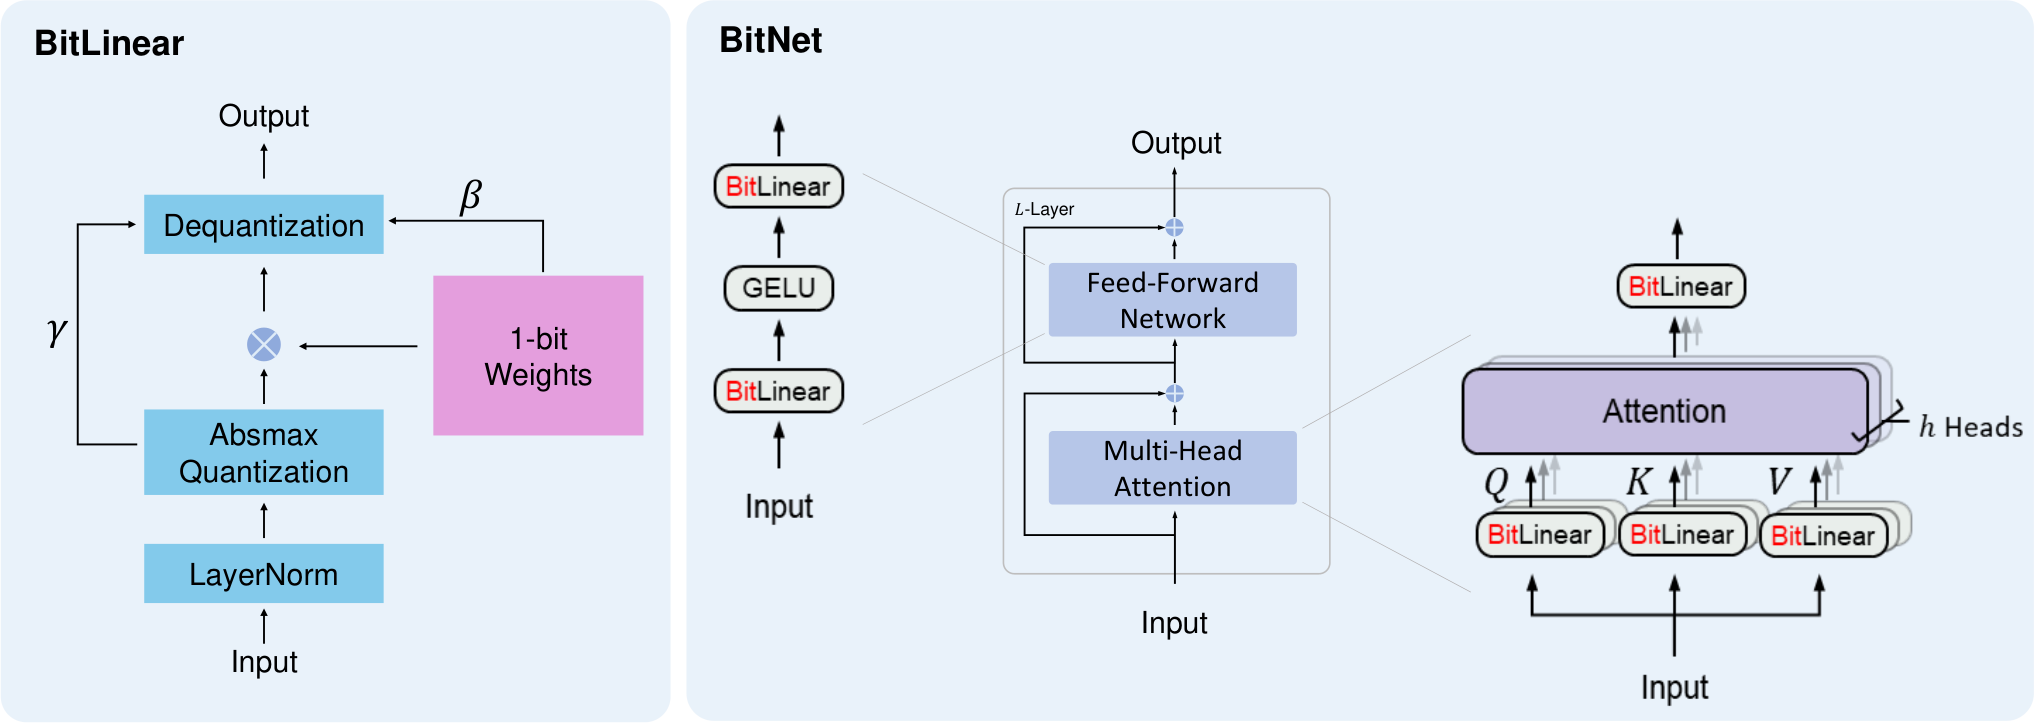

cms-trigger-flow-pierini: 67727d44f5e77f558c03d8d61108a16388c7f895357a3e43f18968f857035bfe | CMS trigger data-flow figure credited to M. Pierini in the conference poster.


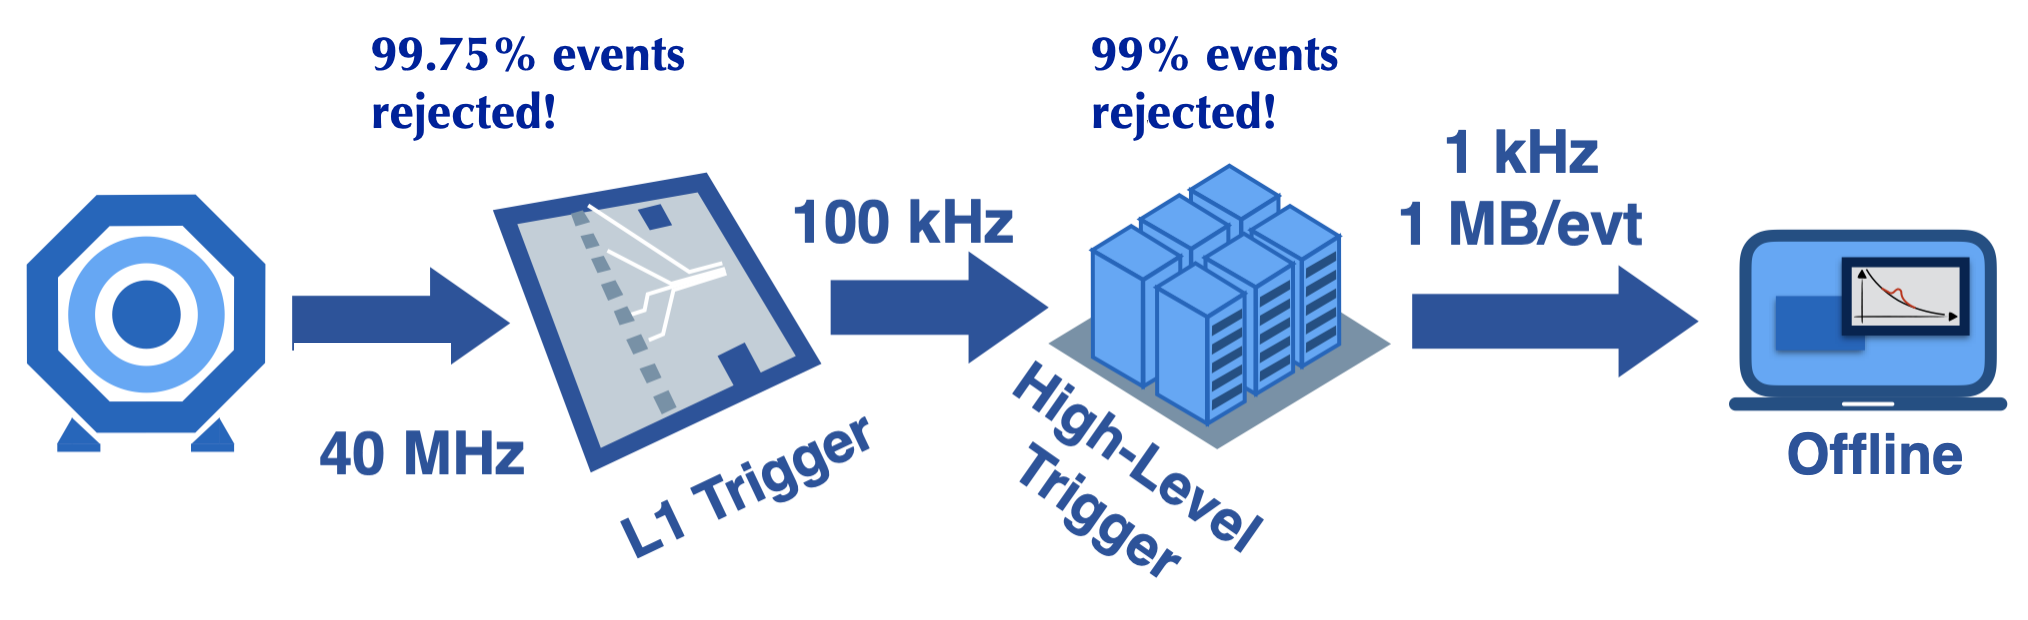

In [8]:
references = [
    ("bitnet-explainer-wang-fig2", source_path(ROOT / "bitnet-arch.png"),
     "Wang et al., BitNet, arXiv:2310.11453, Fig. 2."),
    ("cms-trigger-flow-pierini", source_path(ROOT / "ByMaurizio.png"),
     "CMS trigger data-flow figure credited to M. Pierini in the conference poster."),
]
for name, src, credit in references:
    dst = OUT / f"{name}{src.suffix.lower()}"
    shutil.copy2(src, dst)
    digest = hashlib.sha256(dst.read_bytes()).hexdigest()
    ASSETS.append({
        "name": name, "kind": "reference-only",
        "outputs": [bundle_relative(dst)], "sources": [relative(src)],
        "sha256": digest, "credit": credit,
        "caption": credit,
    })
    print(f"{name}: {digest} | {credit}")
    display(Image(filename=str(dst)))

## 9 — write and audit the bundle manifest

In [9]:
manifest = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "generator": "nrp-lab/notebooks/04_conference_figures_pre_ebops.ipynb",
    "scope": "fixed-precision Round 14 conference visuals before EBOPs-target enforcement",
    "included_roots": [
        "bnjettag/roc-results/r14",
        "bnjettag/results/r14/ebops_r14.json",
        "bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-beta1sm4i0",
        "docs/figures/bnjettag-architecture.tex",
    ],
    "excluded_tokens": list(FORBIDDEN),
    "auc_gate": "60/60 .npz arrays recomputed; metadata macro AUC matched to <1e-12",
    "assets": ASSETS,
}
manifest_path = OUT / "manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2) + "\n")

forbidden_hits = [
    source for asset in ASSETS for source in asset.get("sources", [])
    if any(token in source for token in FORBIDDEN)
]
assert not forbidden_hits, forbidden_hits
generated = [asset for asset in ASSETS if asset["kind"] != "reference-only"]
assert len(generated) == 8, [(asset["name"], asset["kind"]) for asset in ASSETS]

print(f"bundle complete: {len(ASSETS)} assets ({len(generated)} generated, 2 reference-only)")
print("manifest:", manifest_path)
for asset in ASSETS:
    print("\n-", asset["name"], f"[{asset['kind']}]")
    print("  output :", ", ".join(asset["outputs"]))
    print("  source :", ", ".join(asset["sources"]))
    print("  caption:", asset["caption"])

bundle complete: 10 assets (8 generated, 2 reference-only)
manifest: /Users/kaiyamaguchi/Desktop/bnjettag-lab/local/outputs/conference-pre-ebops/manifest.json

- fig_auc_vs_n_conference_pre_ebops [generated-plot]
  output : fig_auc_vs_n_conference_pre_ebops.png, fig_auc_vs_n_conference_pre_ebops.pdf
  source : bnjettag/roc-results/r14/n8/FP32-s1.npz, bnjettag/roc-results/r14/n8/FP32-s2.npz, bnjettag/roc-results/r14/n8/FP32-s3.npz, bnjettag/roc-results/r14/n8/W8A8-s1.npz, bnjettag/roc-results/r14/n8/W8A8-s2.npz, bnjettag/roc-results/r14/n8/W8A8-s3.npz, bnjettag/roc-results/r14/n8/W1A8-s1.npz, bnjettag/roc-results/r14/n8/W1A8-s2.npz, bnjettag/roc-results/r14/n8/W1A8-s3.npz, bnjettag/roc-results/r14/n8/W1A6-s1.npz, bnjettag/roc-results/r14/n8/W1A6-s2.npz, bnjettag/roc-results/r14/n8/W1A6-s3.npz, bnjettag/roc-results/r14/n8/W1A4-s1.npz, bnjettag/roc-results/r14/n8/W1A4-s2.npz, bnjettag/roc-results/r14/n8/W1A4-s3.npz, bnjettag/roc-results/r14/n16/FP32-s1.npz, bnjettag/roc-results/r14/n16/FP

---
**Expected bundle:** AUC-vs-N, AUC-vs-EBOPs, four ROC overlays, LUT
attribution, the architecture diagram, two credited context images, the
recomputed AUC CSV, and `manifest.json`. The manifest is the audit trail and
the machine-readable statement that no EBOPs-target-enforcement result entered
the conference visuals.